## Cell 1 — Check GPU

In [1]:
import torch

print("CUDA Available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU not available. Set Runtime → Change runtime type → T4 GPU.")


CUDA Available: True
GPU: Tesla T4


## Cell 2 — Mount Drive (Recommended)

In [2]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## Cell 3 — Push Your Code First, Then Clone Here

> ⚠️ **Run this on your local machine BEFORE opening Colab:**
> ```bash
> git add .
> git commit -m "diff-gaussian-rasterization migration"
> git push origin main
> ```
> Colab only reads from GitHub. If you have unpushed local changes
> (e.g. the migrated `renderer.py`, `trainer.py`, `gaussian_model.py`,
> `loss.py`, `sh_utils.py`, `general_utils.py`), they will NOT be
> present in Colab until they are pushed.

Edit `REPO_URL` below to match your repository.

In [3]:
REPO_URL = "https://github.com/Somaskandan931/Monosplat.git"

import os

if os.path.isdir("/content/monosplat/.git"):
    print("Repo already cloned — pulling latest changes...")
    !git -C /content/monosplat pull --ff-only
else:
    print("Fresh clone...")
    !git clone {REPO_URL} /content/monosplat

%cd /content/monosplat
!git log --oneline -5   # confirm which commit is running

# ── Verify the migrated files are present ────────────────────────────────
# If any of these are missing, you have unpushed local changes.
# Fix: push from your machine and re-run this cell.
REQUIRED = [
    "src/renderer/renderer.py",
    "src/reconstruction/trainer.py",
    "src/reconstruction/gaussian_model.py",
    "src/reconstruction/loss.py",
    "src/utils/sh_utils.py",
    "src/utils/general_utils.py",
    "requirements-colab.txt",
    "colab/train.py",
    "configs/config.yaml",
]

all_ok = True
for path in REQUIRED:
    exists = os.path.exists(f"/content/monosplat/{path}")
    status = "✓" if exists else "✗ MISSING — push this file from your local machine"
    if not exists:
        all_ok = False
    print(f"  {status}  {path}")

if not all_ok:
    raise FileNotFoundError(
        "\n\nOne or more required files are missing from the cloned repo.\n"
        "Push them from your local machine and re-run this cell.\n"
        "  cd D:/PycharmProjects/monosplat\n"
        "  git add .\n"
        "  git commit -m 'update'\n"
        "  git push origin main"
    )
else:
    print("\n✅ All required files present — repo is up to date.")


Fresh clone...
Cloning into '/content/monosplat'...
remote: Enumerating objects: 270, done.
remote: Counting objects: 100% (264/264), done.
remote: Compressing objects: 100% (196/196), done.
remote: Total 270 (delta 81), reused 228 (delta 55), pack-reused 6 (from 1)
Receiving objects: 100% (270/270), 490.02 KiB | 2.38 MiB/s, done.
Resolving deltas: 100% (81/81), done.
/content/monosplat
237e485 (HEAD -> main, origin/main, origin/HEAD) New commit
6be8a75 New commit
6dce964 New commit


## Cell 3b — Install diff-gaussian-rasterization & simple-knn

Builds the original 3DGS CUDA kernels from the graphdeco submodules.
This replaces gsplat — run once per Colab session.

In [ ]:
import os, subprocess, sys

GS_DIR   = "/content/gaussian-splatting"
DGR_DIR  = os.path.join(GS_DIR, "submodules", "diff-gaussian-rasterization")
KNN_DIR  = os.path.join(GS_DIR, "submodules", "simple-knn")

# ── 1) Clone gaussian-splatting ──────────────────────────────────────────────
# NOTE: do NOT use --depth 1 here.
# Shallow clones prevent `git submodule update --init --recursive` from
# fetching nested submodules (e.g. third_party/glm inside each submodule).
# Without glm the CUDA build fails with: fatal error: glm/glm.hpp: No such file
if not os.path.isdir(os.path.join(GS_DIR, ".git")):
    print("Cloning gaussian-splatting (full, with all nested submodules) ...")
    subprocess.run([
        "git", "clone", "--recurse-submodules",
        "https://github.com/graphdeco-inria/gaussian-splatting.git",
        GS_DIR,
    ], check=True)
else:
    print("gaussian-splatting already cloned.")

# ── 2) Ensure nested submodules are initialised (glm etc.) ───────────────────
# Needed when the repo was cloned in a previous session without --recurse-submodules,
# or when only a shallow clone was available.
for submod_dir in (DGR_DIR, KNN_DIR):
    subprocess.run(
        ["git", "submodule", "update", "--init", "--recursive"],
        cwd=submod_dir, check=True
    )

# Verify glm is present in both submodules before building
for submod_dir in (DGR_DIR, KNN_DIR):
    glm_h = os.path.join(submod_dir, "third_party", "glm", "glm", "glm.hpp")
    assert os.path.exists(glm_h), (
        f"glm header still missing after submodule init: {glm_h}\n"
        "Run: git submodule update --init --recursive  inside each submodule dir."
    )
    print(f"glm OK: {glm_h}")

# ── 3) Build deps ─────────────────────────────────────────────────────────────
subprocess.run(["apt-get", "install", "-y", "-q", "ninja-build"], check=True)
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "ninja"], check=True)

os.environ["CUDA_HOME"] = "/usr/local/cuda"
os.environ["MAX_JOBS"]  = "1"   # prevents OOM during parallel nvcc on T4

# ── 4) Build & install diff-gaussian-rasterization ───────────────────────────
print("\nInstalling diff-gaussian-rasterization ...")
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "--no-build-isolation", "--no-cache-dir", DGR_DIR],
    check=True,
)

# ── 5) Build & install simple-knn ────────────────────────────────────────────
print("Installing simple-knn ...")
subprocess.run(
    [sys.executable, "-m", "pip", "install",
     "--no-build-isolation", "--no-cache-dir", KNN_DIR],
    check=True,
)

# ── 6) Sanity-check imports ───────────────────────────────────────────────────
from diff_gaussian_rasterization import GaussianRasterizer   # noqa
from simple_knn._C import distCUDA2                          # noqa
print("\n\u2705 diff-gaussian-rasterization and simple-knn installed successfully.")


## Cell 4 — Install Python Dependencies

Installs project requirements from `requirements-colab.txt`.
`diff-gaussian-rasterization` and `simple-knn` are already installed
by Cell 3b above — they are **not** in `requirements-colab.txt`.

In [4]:
import subprocess, sys, os

# Install project requirements (gsplat has been removed from this file;
# diff-gaussian-rasterization and simple-knn come from the submodule build above).
req = "requirements-colab.txt" if os.path.exists("requirements-colab.txt") else "requirements.txt"
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", req], check=True)

print("\n✅ Python dependencies installed")



✅ Dependencies installed


## Cell 5 — Upload Package

Upload your `colab_training_package.zip` when the file picker appears.

In [5]:
from google.colab import files

uploaded = files.upload()  # select colab_training_package.zip


Saving colab_training_package.zip to colab_training_package.zip


## Cell 6 — Extract Package

Expected structure inside the zip:
```
frames/
sparse_text/
```

In [6]:
import zipfile
from pathlib import Path

zip_name = next(n for n in uploaded if n.lower().endswith(".zip"))
DATASET  = Path("/content/dataset")
DATASET.mkdir(parents=True, exist_ok=True)

with zipfile.ZipFile(zip_name) as zf:
    zf.extractall(DATASET)

# Unwrap single nested directory if present
entries = [p for p in DATASET.iterdir()]
if len(entries) == 1 and entries[0].is_dir():
    DATASET = entries[0]

print("Dataset root:", DATASET)
print("Contents:", [p.name for p in DATASET.iterdir()])


Dataset root: /content/dataset
Contents: ['frames', 'sparse_text']


## Cell 7 — Verify Dataset

All files should show ✓ before training.

In [7]:
from pathlib import Path

required = [
    DATASET / "sparse_text" / "cameras.txt",
    DATASET / "sparse_text" / "images.txt",
    DATASET / "sparse_text" / "points3D.txt",
]

for f in required:
    print(f.name, "✓" if f.exists() else "✗ MISSING")

frames_dir = DATASET / "frames"
if frames_dir.exists():
    n = sum(1 for f in frames_dir.iterdir() if f.suffix.lower() in {".jpg", ".jpeg", ".png"})
    print(f"frames/ ✓  ({n} images)")
else:
    print("frames/ ✗ MISSING")


cameras.txt ✓
images.txt ✓
points3D.txt ✓
frames/ ✓  (75 images)


## Cell 8 — Training

Reads all settings from `configs/config.yaml` in the repository. Exports `final.ply`, `final.splat`, and `training.log` automatically when done.

> `training.log` is written live to `exports/training.log` as training runs — the complete log is preserved even if the session disconnects mid-run.

In [8]:
import subprocess, sys, os
from pathlib import Path

REPO_DIR   = Path("/content/monosplat")
OUTPUT_DIR = Path("/content/output")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Training log is saved to exports/ alongside final.splat and final.ply
LOG_PATH = OUTPUT_DIR / "exports" / "training.log"
LOG_PATH.parent.mkdir(parents=True, exist_ok=True)

cmd = [
    sys.executable,
    str(REPO_DIR / "colab" / "train.py"),
    "--sparse", str(DATASET / "sparse_text"),
    "--frames", str(DATASET / "frames"),
    "--output", str(OUTPUT_DIR),
    "--config", str(REPO_DIR / "configs" / "config.yaml"),
]

env = os.environ.copy()
env["PYTHONPATH"]              = f"{REPO_DIR / 'src'}:{REPO_DIR}"
env["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True,max_split_size_mb:128"

# ── Live streaming + simultaneous log write ──────────────────────────────
# Every log line is printed to the cell output AND written to training.log
# so the complete run history is preserved even on mid-run disconnects.

proc = subprocess.Popen(
    cmd,
    env=env,
    cwd=str(REPO_DIR),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,   # merge stderr → stdout so order is preserved
    bufsize=1,                  # line-buffered
    text=True,
)

print("Training started — streaming output below.")
print("Watch for:")
print("  iter XXXX/20000  loss=0.XXXX  N=XX,XXX")
print("  [Trainer] Preview saved: .../preview_000250.png")
print("-" * 60)

with open(LOG_PATH, "w", buffering=1) as log_file:
    for line in proc.stdout:
        print(line, end="", flush=True)  # live cell output
        log_file.write(line)             # simultaneous log write

proc.wait()
if proc.returncode != 0:
    raise RuntimeError(f"Training failed (exit {proc.returncode})")

print("-" * 60)
print("\n✅ Training complete")
print(f"   Log saved → {LOG_PATH}  ({LOG_PATH.stat().st_size / 1e3:.1f} KB)")


Training started — streaming output below.
Watch for:
  iter XXXX/12000  loss=0.XXXX  N=XX,XXX
  [DENSIFY] iter=600  before=20000  after=22000+
  [Trainer] Preview saved: .../preview_000250.png
------------------------------------------------------------
2026-06-05 17:39:10,255 [INFO] __main__ — [checkpoint] Fresh start (no checkpoint found).
2026-06-05 17:39:10,256 [INFO] __main__ — ============================================================
2026-06-05 17:39:10,256 [INFO] __main__ — EFFECTIVE TRAINING CONFIG (after all overrides)
2026-06-05 17:39:10,256 [INFO] __main__ —   iterations             : 20000
2026-06-05 17:39:10,256 [INFO] __main__ —   max_gaussians          : 200000
2026-06-05 17:39:10,256 [INFO] __main__ —   densify_from/until     : 999999 → 0
2026-06-05 17:39:10,256 [INFO] __main__ —   densification_interval : 200
2026-06-05 17:39:10,256 [INFO] __main__ —   densify_grad_threshold : 0.0002
2026-06-05 17:39:10,256 [INFO] __main__ —   lambda_dssim           : 0.2
2026-06-0

## Cell 8b — View Training Previews

Run this any time during or after training to see the latest preview renders.

80 preview(s) available — showing latest 4:

  Iteration 19,250


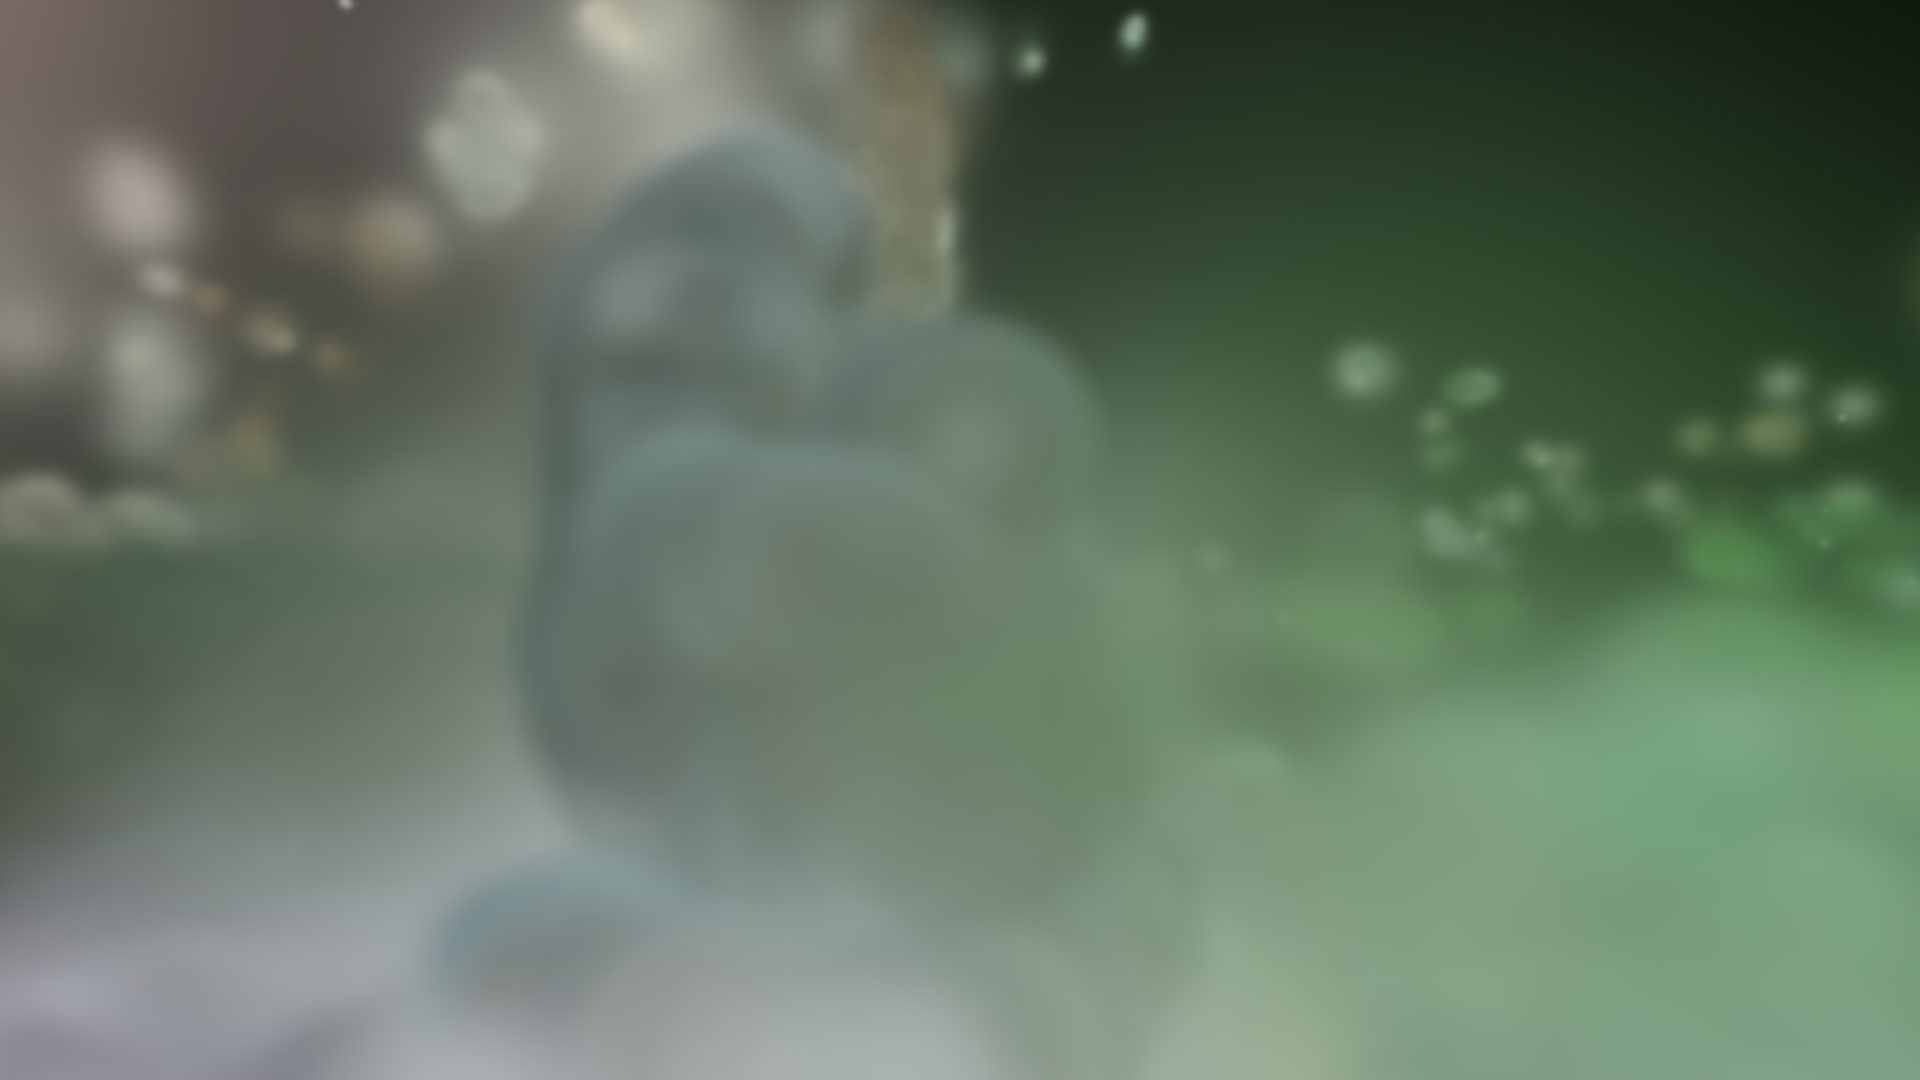


  Iteration 19,500


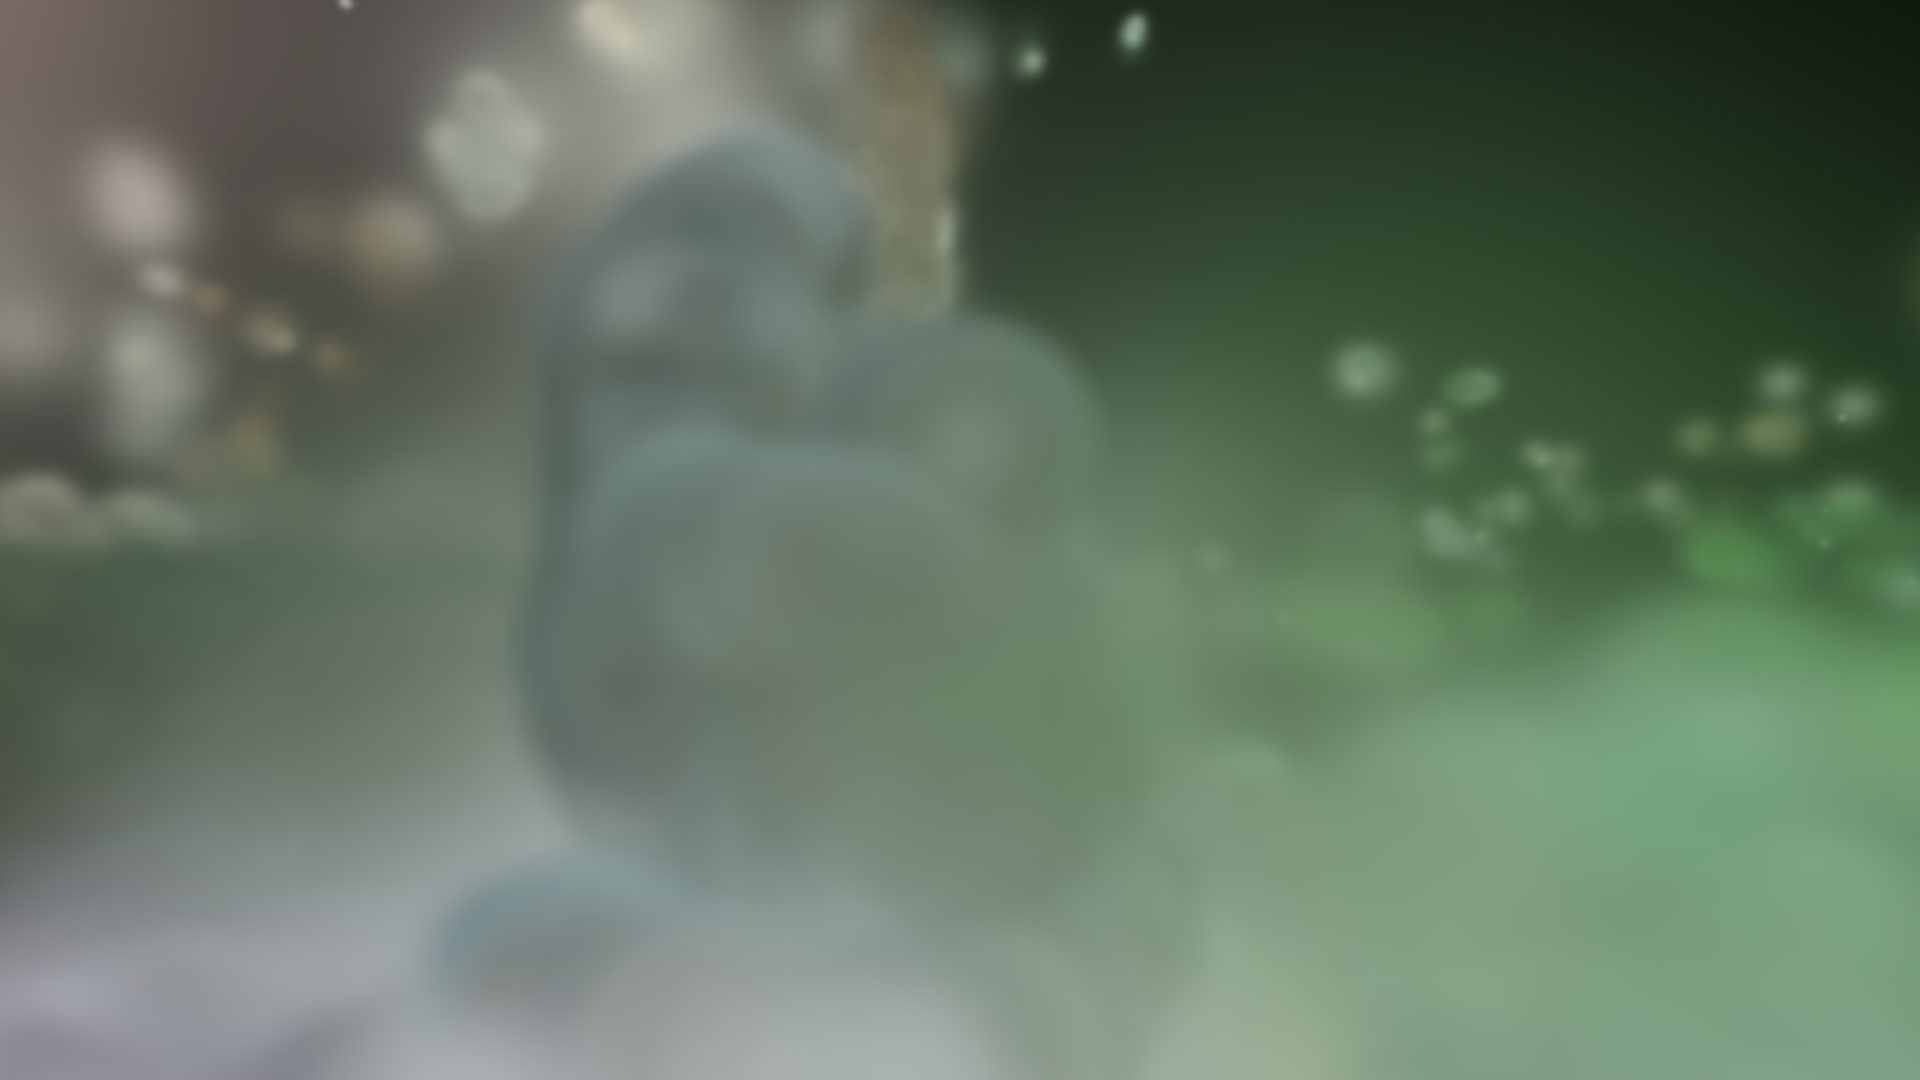


  Iteration 19,750


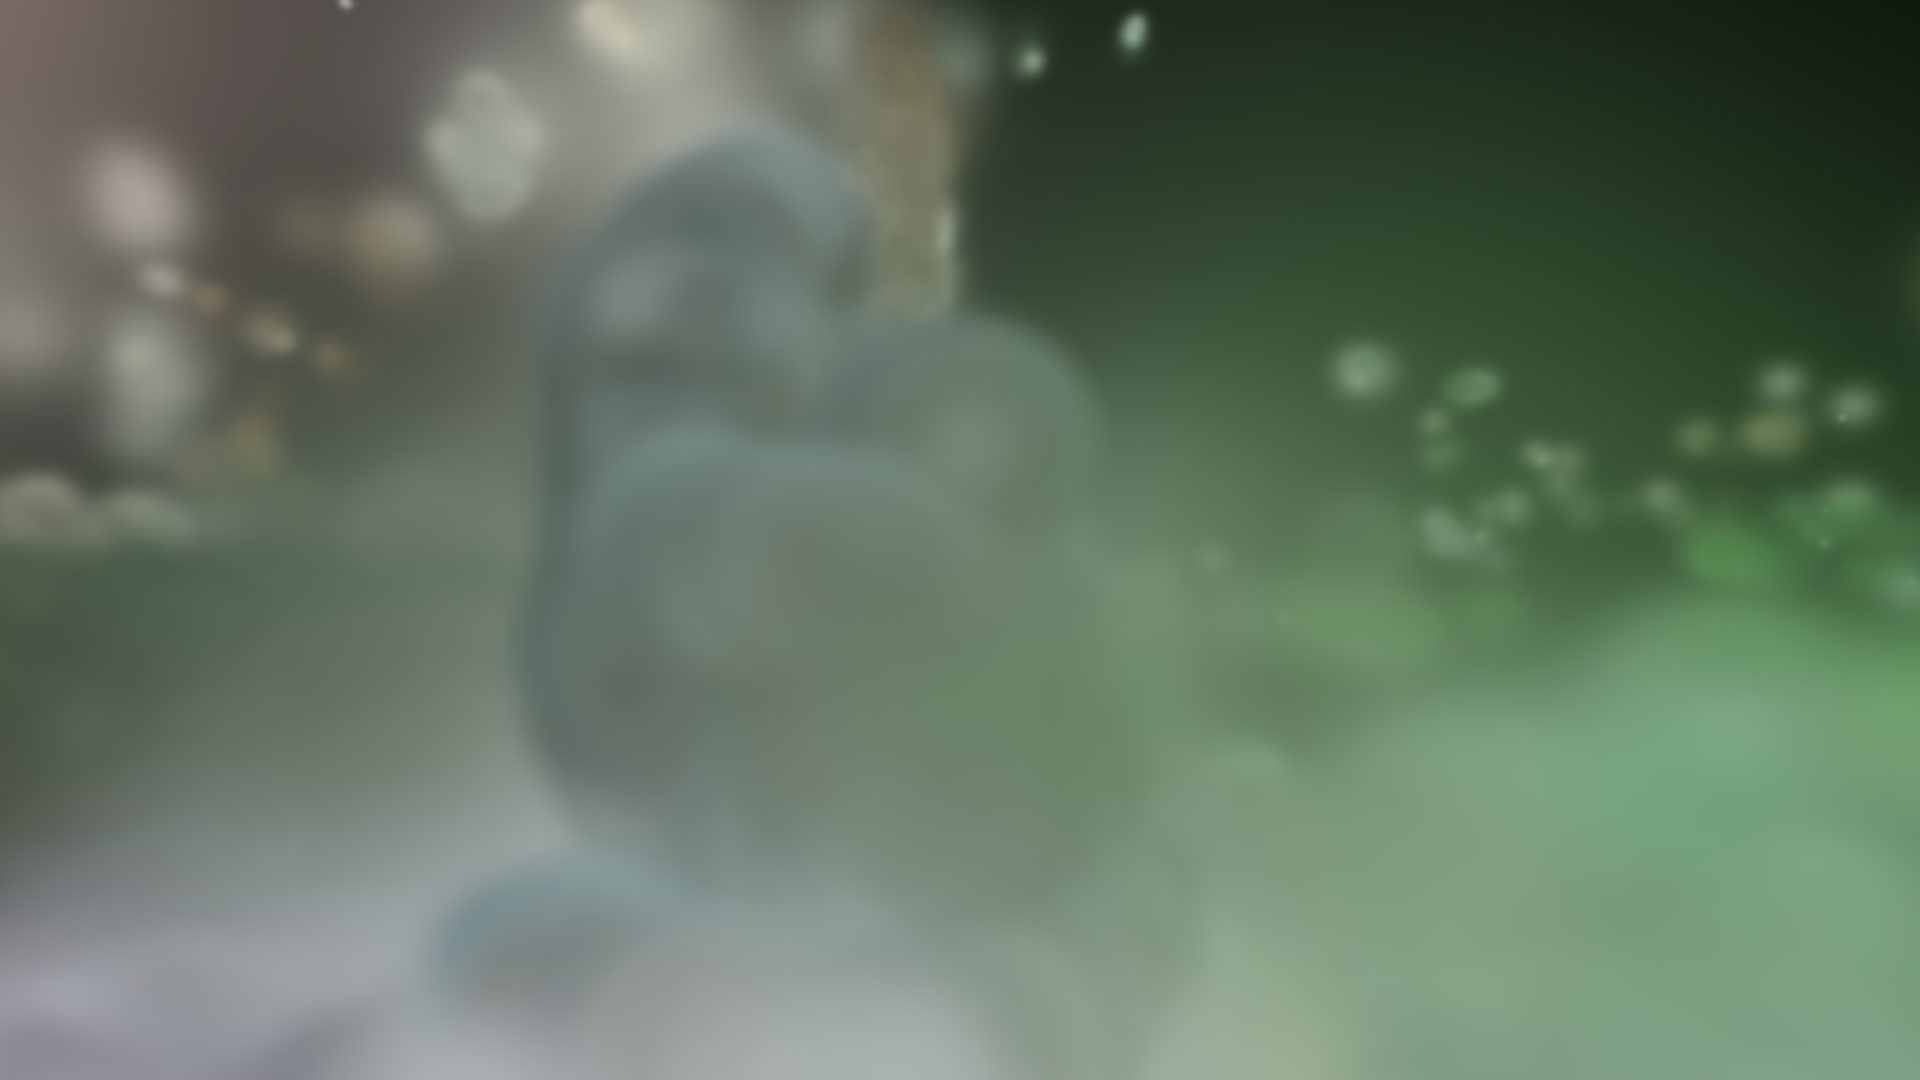


  Iteration 20,000


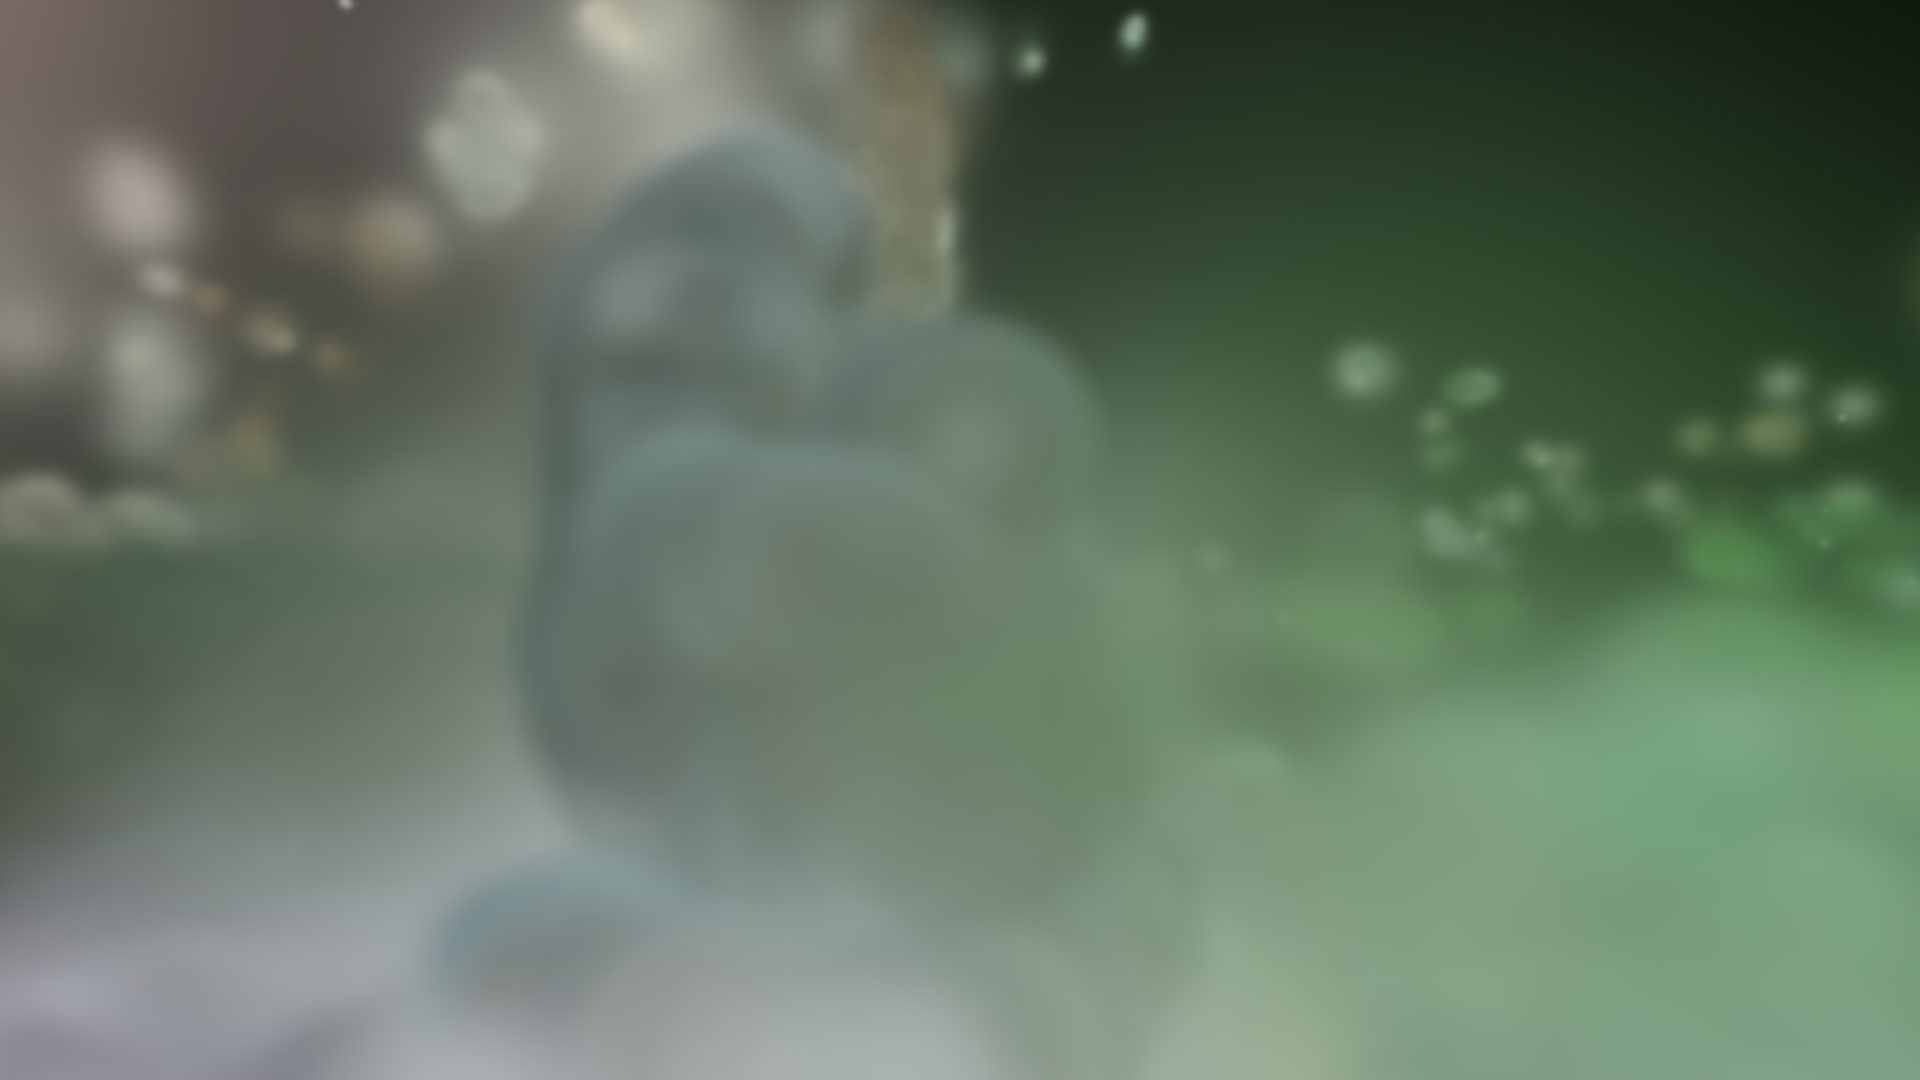

In [9]:
from pathlib import Path
from IPython.display import display, Image as IPImage
import ipywidgets as widgets

preview_dir = Path("/content/output/previews")

if not preview_dir.exists() or not list(preview_dir.glob("*.png")):
    print("No previews yet — training saves one every 250 iterations.")
    print("Re-run this cell after the first few hundred iterations.")
else:
    previews = sorted(preview_dir.glob("preview_*.png"))
    print(f"{len(previews)} preview(s) available — showing latest 4:\n")

    for p in previews[-4:]:
        iter_num = int(p.stem.replace('preview_', ''))
        print(f"  Iteration {iter_num:,}")
        display(IPImage(filename=str(p), width=480))
        print()


## Cell 9 — Validate Outputs

You should see `final.splat`, `final.ply`, and at least one `checkpoint_*.ckpt`.

In [10]:
from pathlib import Path

for f in sorted(Path("/content/output").rglob("*")):
    if f.is_file():
        print(f"  {f.relative_to('/content/output')}  ({f.stat().st_size / 1e6:.1f} MB)")


  checkpoints/checkpoint_000500.ckpt  (4.7 MB)
  checkpoints/checkpoint_001000.ckpt  (4.7 MB)
  checkpoints/checkpoint_001500.ckpt  (4.7 MB)
  checkpoints/checkpoint_002000.ckpt  (4.7 MB)
  checkpoints/checkpoint_002500.ckpt  (4.7 MB)
  checkpoints/checkpoint_003000.ckpt  (4.7 MB)
  checkpoints/checkpoint_003500.ckpt  (4.7 MB)
  checkpoints/checkpoint_004000.ckpt  (4.7 MB)
  checkpoints/checkpoint_004500.ckpt  (4.7 MB)
  checkpoints/checkpoint_005000.ckpt  (4.7 MB)
  checkpoints/checkpoint_005500.ckpt  (4.7 MB)
  checkpoints/checkpoint_006000.ckpt  (4.7 MB)
  checkpoints/checkpoint_006500.ckpt  (4.7 MB)
  checkpoints/checkpoint_007000.ckpt  (4.7 MB)
  checkpoints/checkpoint_007500.ckpt  (4.7 MB)
  checkpoints/checkpoint_008000.ckpt  (4.7 MB)
  checkpoints/checkpoint_008500.ckpt  (4.7 MB)
  checkpoints/checkpoint_009000.ckpt  (4.7 MB)
  checkpoints/checkpoint_009500.ckpt  (4.7 MB)
  checkpoints/checkpoint_010000.ckpt  (4.7 MB)
  checkpoints/checkpoint_010500.ckpt  (4.7 MB)
  checkpoints

## Cell 9b — Metrics

PSNR / SSIM / LPIPS on held-out test views (every 8th frame).

In [ ]:
import json
from pathlib import Path

mpath = Path("/content/output/exports/metrics.json")
if mpath.exists():
    print(json.dumps(json.load(open(mpath)), indent=2))
else:
    print("metrics.json not found — check training.log for errors.")


## Cell 10 — Save to Drive

In [11]:
import shutil

DRIVE_DST = "/content/drive/MyDrive/MonoSplatResults"
shutil.copytree("/content/output", DRIVE_DST, dirs_exist_ok=True)
print("✅ Saved to", DRIVE_DST)


✅ Saved to /content/drive/MyDrive/MonoSplatResults


## Cell 11 — Download SPLAT + Log

Downloads `final.splat` and `training.log` from `exports/`.

In [12]:
from google.colab import files

files.download("/content/output/exports/final.splat")
files.download("/content/output/exports/training.log")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>